In [1]:
import pandas as pd
import seaborn as sns
insurance_data=pd.read_csv("insurance_csv.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

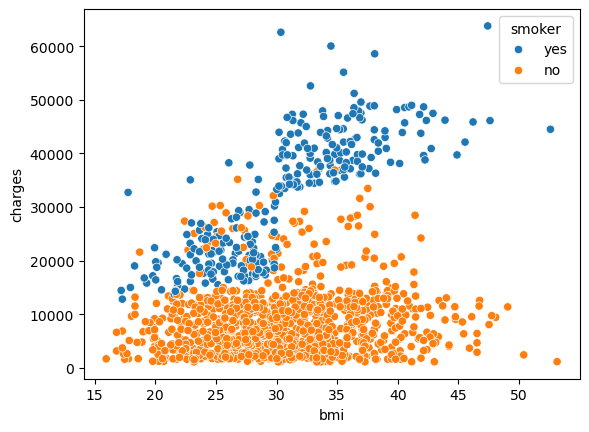

In [2]:
sns.scatterplot(
    x=insurance_data["bmi"],
    y=insurance_data["charges"],
    hue=insurance_data["smoker"])

In [3]:
import pandas as pd
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [4]:
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
x.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
764,45,1,25.175,2,0,0,0,0,0,0.000
887,36,1,30.020,0,0,1,0,0,0,0.000
890,64,1,26.885,0,1,1,0,0,64,26.885
1293,46,0,25.745,3,0,1,0,0,0,0.000
259,19,0,31.920,0,1,1,0,0,19,31.920


In [6]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_train_pred=model.predict(x_test)
r2_train=r2_score(y_test,y_train_pred)
print(r2_train)
print(r2)


NameError: name 'r2_score' is not defined

In [ ]:
y_test

In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

In [ ]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
insurance_data=pd.read_csv("insurance_csv.csv")

In [ ]:
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [ ]:
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.linear_model import Lasso
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    y_pred=lasso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    print(mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error,r2_score
a=[0.0001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42)
lasso_cv_model.fit(x_train,y_train)
print(lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mse)
print(r2)


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score

In [ ]:
df=pd.read_csv("heart.csv")
df.columns

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]
y.head()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train[x_train==1]

In [ ]:

model=LogisticRegression(max_iter=2000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("accuracy score:",accuracy_score(y_test,y_pred)*100,"%")
print("precision:",precision_score(y_test,y_pred)*100,"%")

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


In [ ]:
df=pd.read_csv("heart.csv")

In [ ]:
df.head()

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
gnb_model=GaussianNB()
gnb_model.fit(x_train,y_train)
y_pred=gnb_model.predict(x_test)

In [ ]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
df=pd.read_csv("heart.csv")
df


In [ ]:
x=df.drop("target",axis=1)
y=df["target"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
classifier=KNeighborsClassifier()
param_grid={"n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5)
classifierCV.fit(x_train_scaled,y_train)
y_pred=classifierCV.predict(x_test_scaled)


In [ ]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
results=pd.DataFrame(classifierCV.cv_results_)
print(results[["param_n_neighbors","mean_test_score"]])
print(classifierCV.best_params_)

In [ ]:
from sklearn.pipeline import Pipeline
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
pipe=Pipeline([("scaler",StandardScaler()),
                   ("knn",KNeighborsClassifier())])
param_grid={"knn__n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="recall")
classifierCV.fit(x_train,y_train)
y_pred=classifierCV.predict(x_test)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print(classifierCV.best_params_)



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("loan_approval_data.csv")
df.head()

In [ ]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [ ]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [ ]:
df.head()


In [ ]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


In [ ]:
edu_dnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_dnt)


In [ ]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20)

In [ ]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=5)

In [ ]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income")

In [ ]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

In [ ]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [ ]:
df=df.drop("Applicant_ID",axis=1)
df.head()


In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()
df.columns

In [ ]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
one=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=one.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=one.get_feature_names_out(cols),index=df.index)

In [ ]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)
df.head()

In [ ]:
df.head()

In [ ]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm")



In [ ]:
num_cols.corr()["Loan_Approved"]


In [ ]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

In [ ]:
x=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:


from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
tit=sns.load_dataset("titanic")

In [ ]:
tit.head()
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [ ]:
tit.isnull().sum()

In [ ]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
tit["age"]=imp_median.fit_transform(tit[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
tit["embarked"]=imp_freq.fit_transform(tit[["embarked"]]).ravel()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
tit["sex"]=le.fit_transform(tit["sex"])
tit["embarked"]=le.fit_transform(tit["embarked"])

In [ ]:
x=tit[features]
y=tit[target]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy score:",(y_test,y_pred))

In [ ]:
from  sklearn.tree import plot_tree
plt.figure(figsize =(18,10)),
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True,
          max_depth=4)
plt.tight_layout()
plt.show()
          

In [ ]:
max_depths=[2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f" for depth={depth},accuracy={acc}")
    if depth==4:
       plt.figure(figsize=(18,10)),
       plot_tree(model,
              feature_names=x.columns,
              class_names=["died","survived"],
      filled=True)
plt.tight_layout()
plt.show()


In [ ]:
min_samples_split=[5,10,15,20,25,30]
for split in min_samples_split:
    model=DecisionTreeClassifier(max_depth=4,
                                 min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for sample split={split},accuracy={acc}")
    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(model,
        feature_names=x.columns,
        class_names=["died","survived"],
        filled=True)
        plt.tight_layout()
        plt.show()

In [ ]:
full_tree=DecisionTreeClassifier(random_state=42)

In [ ]:
full_tree.fit(x_train,y_train)
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

In [ ]:
trees=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    trees.append((model,alpha))
    best_acc=0
    best_alpha=0
    for model,alpha in trees:
        curr_acc=model.score(x_test,y_test)
        if curr_acc>best_acc:
            best_acc=curr_acc
            best_alpha=alpha
    

In [ ]:
best_acc

In [ ]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=4)
best_model.fit(x_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["died","survived"],
    filled=True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
df=load_diabetes(as_frame=True).frame
x=df.drop("target",axis=1)
y=df["target"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=7,min_samples_leaf=20)
model.fit(x_train,y_train)
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("MSE train:",(y_train,y_pred_train))
print("MSE test:",(y_test,y_pred_test))

In [ ]:
print("r2 train:",r2_score(y_train,y_pred_train))
print("r2 test:",r2_score(y_test,y_pred_test))

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [ ]:
df=datasets.load_iris(as_frame=True).frame

In [ ]:
df.isnull().sum()

In [ ]:
df.shape

In [ ]:
df.head()


In [ ]:
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
svc=SVC()
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score,classification_report
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

In [ ]:
svc=SVC(kernel="linear")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred))

In [ ]:
svc=SVC(kernel="poly")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))

In [ ]:
svc=SVC(kernel="sigmoid")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))


In [ ]:
c_vals=[0.5,1,2,3,4,5]
for c_val in c_vals:
    svc=SVC(C=c_val,kernel="rbf")
    svc.fit(x_train_scaled,y_train)
    y_pred=svc.predict(x_test_scaled)
    print("c= ",c_val,"& accuracy_score:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.svm import SVR
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn import datasets

In [ ]:
df=datasets.load_diabetes(as_frame=True).frame
df.head()

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_scaler=StandardScaler()
y_train_scaled=y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled=y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

In [ ]:
model=SVR()
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)

In [ ]:
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


In [ ]:
model=SVR(kernel="")
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "C":[1,2,5,10,50,100],
    "kernel":["rbf","linear"],
    "epsilon":[0.01,0.1,0.2,0.3,0.5]}
svr=SVR()
grid_search=GridSearchCV(svr,param_grid,scoring="r2",cv=5)
grid_search.fit(x_train,y_train_scaled)
print("best params_",grid_search.best_params_)


In [ ]:
best_model=SVR(kernel="linear",C=10,epsilon=0.1)
best_model.fit(x_train,y_train_scaled)
y_pred_test=best_model.predict(x_test)
y_pred_train=best_model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_pred_train))
print("test r2:",r2_score(y_test_scaled,y_pred_test))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
titanic=sns.load_dataset("titanic")
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [ ]:
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [ ]:
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [ ]:
x=titanic[features]
y=titanic["survived"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
model=DecisionTreeClassifier(max_depth=4)
model.fit(x_train,y_train)
y_pred_test=model.predict(x_test)
y_pred_train=model.predict(x_train)
print("training accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True)
plt.tight_layout()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print("oob score:",rf.oob_score_*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred))


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
base_model=LogisticRegression(max_iter=1000)
bagging=BaggingClassifier(base_model,
                          n_estimators=201)
bagging.fit(x_train,y_train)
y_pred=bagging.predict(x_test)
print("accuracy socre:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

In [ ]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbr=GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)
gbr.fit(x_train,y_train)
y_pred=gbr.predict(x_test)
print("acdcuracy score:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier


In [ ]:
make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
base_model=DecisionTreeClassifier(
    max_depth=1)

In [ ]:
abc=AdaBoostClassifier(
    estimator=base_model,
    n_estimators=1000,
    random_state=42)

In [ ]:
abc.fit(x_train,y_train)
y_pred=abc.predict(x_test)
print("acc:",accuracy_score(y_test,y_pred))
print("classifiaction report:",classification_report(y_test,y_pred))

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
xgb_clf=xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    val_metric="logloss",
    random_state=42)
xgb_clf.fit(x_train,y_train)
y_pred=xgb_clf.predict(x_test)
print("accuracy sccore:",accuracy_score(y_test,y_pred))
print("classificatiion report:",classification_report(y_test,y_pred))


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
x,y=make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [ ]:
lr=LogisticRegression()
svc=SVC()
dtc=DecisionTreeClassifier()

In [ ]:
voting_clf=VotingClassifier(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)])

In [ ]:
voting_clf.fit(x_train,y_train)
y_pred=voting_clf.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

In [ ]:
from sklearn.datasets import make_regression
x,y=make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
lr=LinearRegression()
svc=SVC()
dtc=DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
vr=VotingRegressor(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)]

In [ ]:
vr.fit(x_train,y_train)


In [ ]:
y_pred=vr.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
print("r2:",r2_score(y_test,y_pred))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
lr=LinearRegression()
svc=SVC(probability=True)
dtc=DecisionTreeClassifier()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

# base models
lr = LogisticRegression(max_iter=1000)
svc = SVC(probability=True)
dtc = DecisionTreeClassifier()

# meta model
meta_model = LogisticRegression(max_iter=1000)

# stacking
stacking_clf = StackingClassifier(
    estimators=[
        ("lr", lr),
        ("svc", svc),
        ("dtc", dtc)
    ],
    final_estimator=meta_model,
    cv=5
)

# FIX y shape
y_train = y_train.values.ravel()

# fit & predict
stacking_clf.fit(x_train, y_train)
y_pred = stacking_clf.predict(x_test)

In [ ]:
import numpy as np
np.bincount(y_train)

In [ ]:
import seaborn as sns
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,
               n_features=2,
               centers=4,
               random_state=42)

In [ ]:
sns.scatterplot(x=x[:,0],y=x[:,1])

In [ ]:
from sklearn.cluster import KMeans
k=4

In [ ]:
kmeans=KMeans(n_clusters=k,
              random_state=42)

In [ ]:
labels=kmeans.fit_predict(x)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
wcss=[]
for k in range(1,100):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)

In [ ]:
sns.lineplot(x=range(1,100),y=wcss,marker="o")

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

In [ ]:
knee=KneeLocator(range(1,100),wcss,curve="convex",direction="decreasing")

In [ ]:
print("optimal k= ",knee.elbow)

In [ ]:
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(x)
    score=silhouette_score(x,labels)
    ss.append(score)
    

In [ ]:
sns.lineplot(x=range(2,21),y=ss,marker="o")

In [ ]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target


In [ ]:
sns.scatterplot(x=x[:,0],y=x[:,2])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_scaled=scaler.fit_transform(x)


In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [ ]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    

In [ ]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(pca_data)

In [ ]:
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)

In [ ]:
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="x",c="red",s=200)

In [ ]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram

In [ ]:
z=linkage(x_scaled,method="ward")
plt.figure(figsize=(12,6))
dendrogram(z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("distance for hiierarchal clustering")

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering (n_clusters=2)
labels=agg.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [ ]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.8,
              min_samples=5)
labels=dbscan.fit_predict(x_scaled)
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)


In [ ]:
from sklearn.datasets import make_moons
x,y=make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42)

In [ ]:
x_scaled=scaler.fit_transform(x)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=10,
              random_state=42)
labels=kmeans.fit_predict(x_scaled)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [ ]:
dbscan=DBSCAN(
    eps=0.5,
    min_samples=5)
labels=dbscan.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris()
x=pd.DataFrame(iris.data)
y=iris.target

In [ ]:
x.shape

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [ ]:
x_scaled.reshape

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [ ]:
x_pca.shape

In [ ]:
print("explained varaince ratio:",pca.explained_variance_ratio_)


In [ ]:
print(pca.components_)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],
            x_pca[:,1],
            c=y)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca for iris dataset")

In [ ]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons


In [ ]:
x,y=make_moons(
    n_samples=1000,
    noise=0.1,
    random_state=42)


In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_scaled.shape

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [ ]:
dbscan=DBSCAN(
    eps=0.18,
    min_samples=5)

In [ ]:
labels=dbscan.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("thyroid_dataset.csv")


In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
df.shape

(6916, 22)

In [5]:
x=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [6]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [7]:
from sklearn.neighbors import LocalOutlierFactor

In [8]:
neighbs=LocalOutlierFactor(contamination=0.036)

In [9]:
labels=neighbs.fit_predict(x_scaled)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)

In [10]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("outliers:",n_outliers)
print("normal:",n_normal)

outliers: 249
normal: 6667


#unsupervised project

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df=pd.read_csv("smartcart_customers.csv")

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [14]:
df.shape

(2240, 22)

In [15]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [16]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [17]:
df["Age"]=2026-df["Year_Birth"]

In [18]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()

In [19]:
df["customer_tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days

In [20]:
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntGoldProds"]

In [21]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [22]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [23]:
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "Graduation":"graduate",
    "Master":"postgraduate",
    "PhD":"postgraduate"})

In [24]:
df["Education"].value_counts()

Education
graduate         1127
postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [25]:
df["living_with"]=df["Marital_Status"].replace({
    "Married":"partner",
    "Together":"partner", 
   "Single":"alone",
   "Divorced":"alone", 
    "Widow":"alone",
    "Alone":"alone",
    "Absurd":"alone",
    "YOLO":"alone"})
    

In [26]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [27]:
df["living_with"].value_counts()

living_with
partner    1444
alone       796
Name: count, dtype: int64

In [28]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_Spending',
       'Total_Children', 'living_with'],
      dtype='object')

In [29]:
cols=['ID', 'Year_Birth', 'Marital_Status', 'Kidhome',
       'Teenhome', 'Dt_Customer']
spending_cols=[
        'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

In [30]:
df_cleaned.shape

(2240, 15)

In [31]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,partner


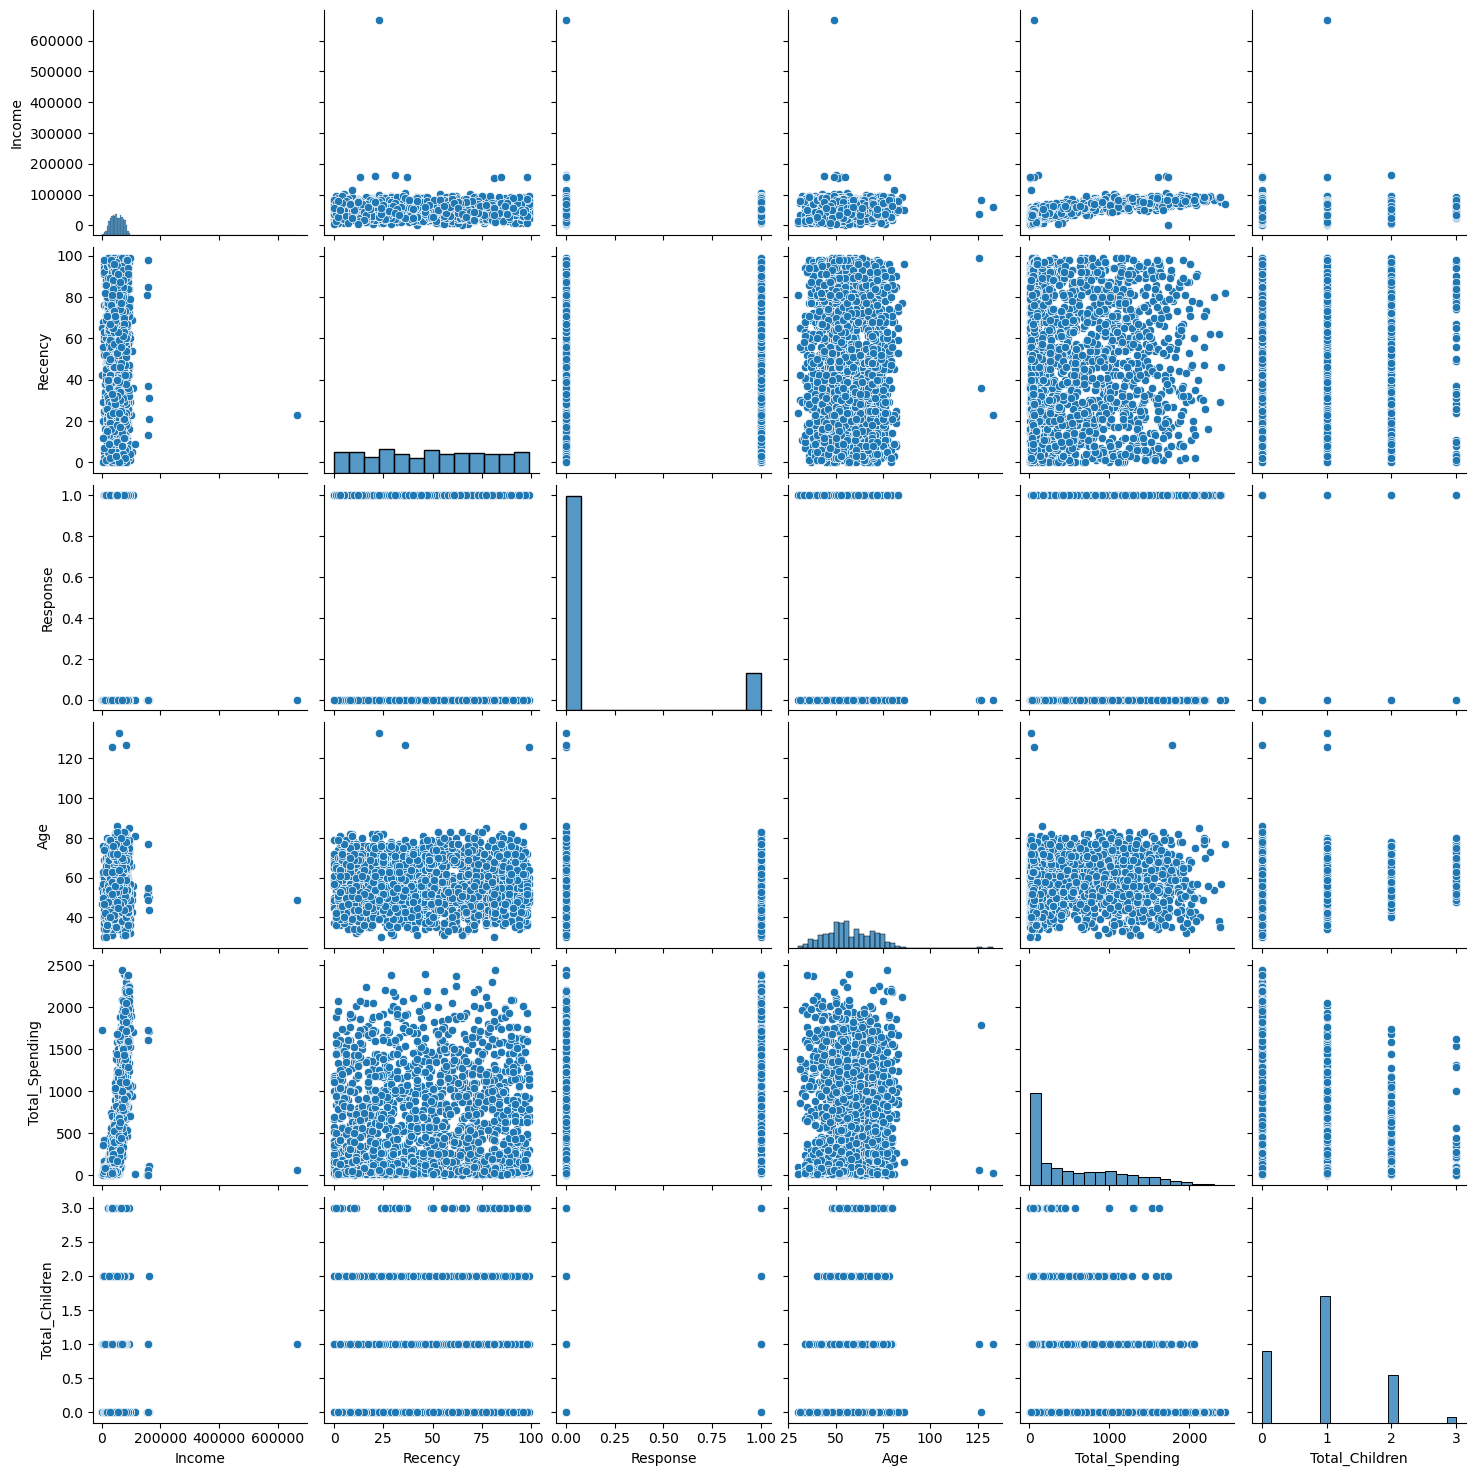

In [32]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [33]:
print("data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size with ouliers:",len(df_cleaned))


data size with outliers: 2240
data size with ouliers: 2236


<Axes: >

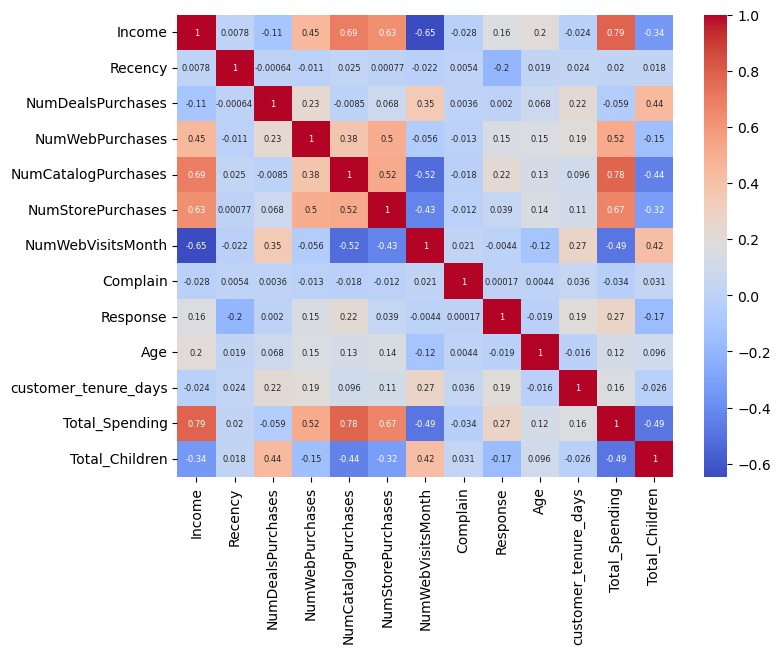

In [34]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm")

In [35]:
df_cleaned.shape

(2236, 15)

In [36]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [37]:
enc_df=pd.DataFrame(enc_cols.toarray(),
columns=ohe.get_feature_names_out(cat_cols),
                    index=df_cleaned.index)
                    

In [38]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [39]:
df_encoded.shape

(2236, 18)

In [40]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_alone,living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,0.0,1.0,0.0,0.0,1.0


In [41]:
from sklearn.preprocessing import StandardScaler
x=df_encoded
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [42]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

In [43]:
pca.explained_variance_ratio_

array([0.23117348, 0.11385549, 0.10409073])

Text(0.5, 0, 'pca3')

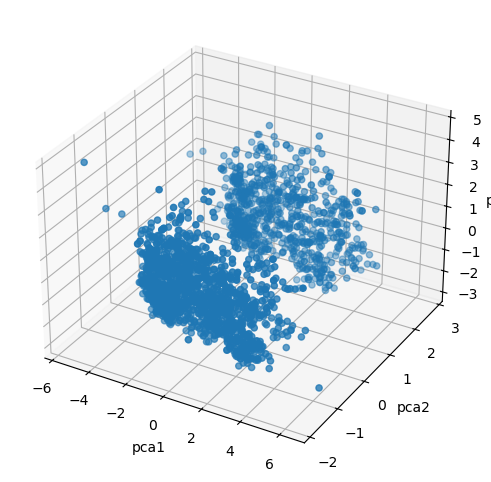

In [44]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")


In [45]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [46]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [47]:
optimal_k=knee.elbow
print("best k= ",optimal_k)


best k=  4


Text(0, 0.5, 'wcss')

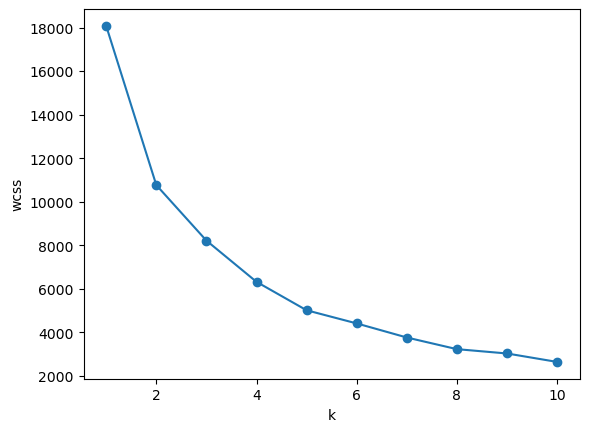

In [48]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss")

In [49]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette socre')

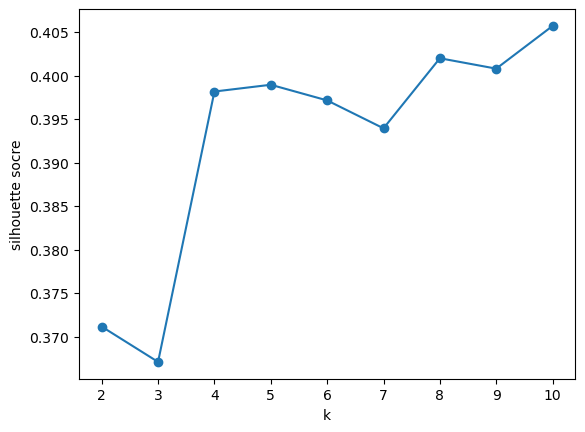

In [50]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette socre")


Text(0, 0.5, 'ss')

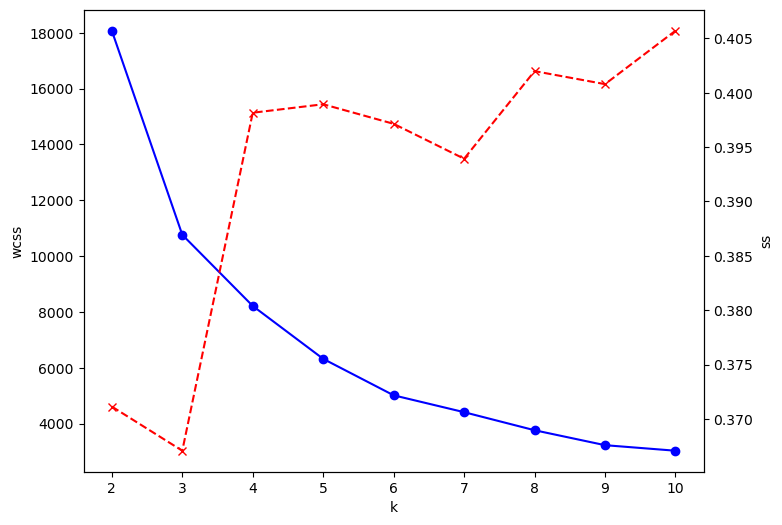

In [51]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("ss")

In [52]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)


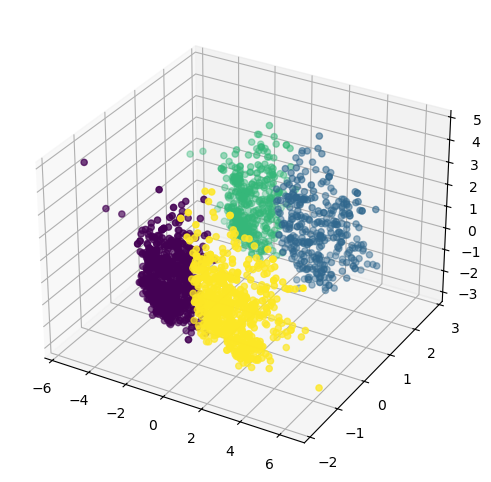

In [53]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [54]:
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels=agg_clf.fit_predict(x_pca)

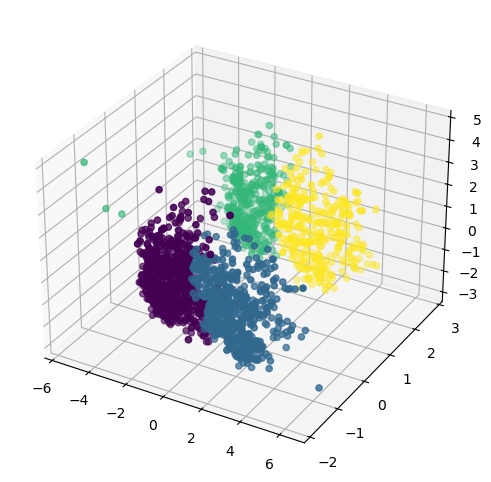

In [55]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [56]:
x["cluster"]=labels
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_alone,living_with_partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

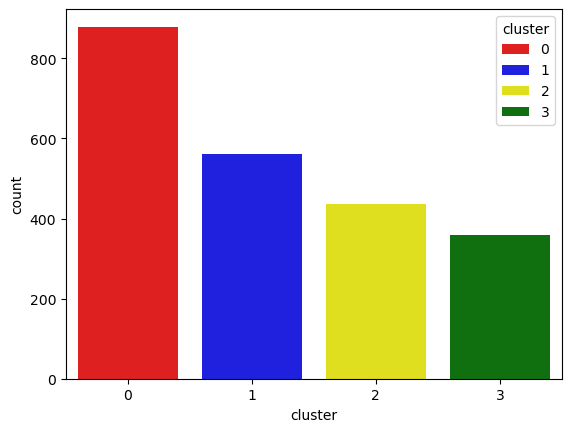

In [57]:
pal=["red","blue","yellow","green"]
sns.countplot(x=x["cluster"],palette=pal,hue=x["cluster"])

MACHINE LEARNING

In [58]:
import pandas as pd
import seaborn as sns
insurance_data=pd.read_csv("insurance_csv.csv")
insurance_data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

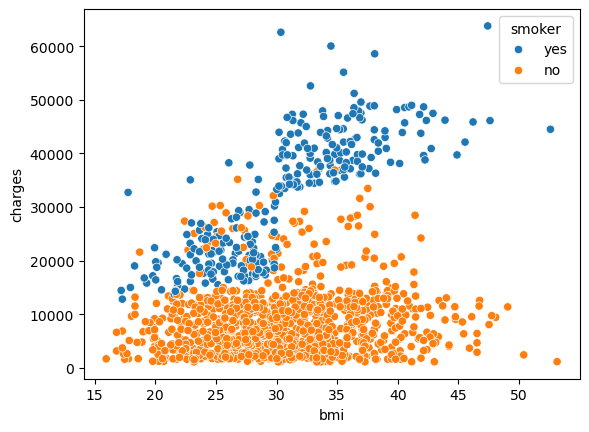

In [59]:
sns.scatterplot(x=insurance_data["bmi"],y=insurance_data["charges"],hue=insurance_data["smoker"])

In [60]:
x=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [62]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [63]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [64]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(adjusted_r2)

0.7811302113434095
0.7769533069797342
